# Tarea 1 — IELE756: Demographic Profile & Migration Landscape
**Team members**: Felipe Alonso, Juan Costa  
**Comunas asignadas**: Quilicura (13122), La Reina (13109), Tiltil (13125)  
**Región**: Metropolitana (13)  
**Date**: Marzo 2026

---
## Parte 0: Carga de datos y joins

El Censo 2024 organiza su información en tres tablas jerárquicas relacionadas:
- **vivienda**: información de la unidad habitacional
- **hogar**: información del hogar dentro de la vivienda
- **persona**: información de cada individuo

Para trabajar eficientemente, cargamos solo las columnas necesarias y filtramos a nuestras comunas lo antes posible, evitando cargar los ~19 millones de filas completos en memoria.

### 0.1 Carga de las tres tablas del Censo

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Códigos numéricos de nuestras comunas asignadas
MY_COMUNAS = [13122, 13109, 13125]  # Quilicura, La Reina, Tiltil

# --- Vivienda ---
vivienda = pd.read_parquet(
    "viviendas_censo2024.parquet",
    columns=["id_vivienda", "region", "comuna"]
)
vivienda = vivienda.rename(columns={'comuna': 'codigo_comuna'}) # Renombramos la columna 'comuna' a 'codigo_comuna' para mantener consistencia con el resto del código.
# Ya que 'nombre_comuna' no está disponible directamente, tendremos que buscar o crear un mapeo si es necesario más adelante.
# Por ahora, se asume que 'codigo_comuna' será suficiente para los filtros iniciales.

# --- Hogar ---
hogar = pd.read_parquet(
    "hogares_censo2024.parquet",
    columns=["id_vivienda", "id_hogar", "p12_tenencia_viv"]
)

# --- Persona ---
persona = pd.read_parquet(
    "personas_censo2024.parquet",
    columns=["id_vivienda", "id_hogar", "id_persona", "sexo", "edad",
             "p27_nacionalidad", "p27_nacionalidad_rec",
             "p24_lug_resid5", "p25_lug_nacimiento",
             "p25_lug_nacimiento_esp","p25_lug_nacimiento_rec", "p26_llegada_periodo", "escolaridad", "cine11",
             "sit_fuerza_trabajo", "cod_ciuo", "cod_caenes",
             "p45_medio_transporte"]
)

print("Tablas cargadas exitosamente.")
print(f"vivienda: {vivienda.shape}")
print(f"hogar:    {hogar.shape}")
print(f"persona:  {persona.shape}")

Tablas cargadas exitosamente.
vivienda: (7664466, 3)
hogar:    (6622597, 3)
persona:  (18480432, 18)


### 0.2 Filtro a las comunas asignadas

Filtramos primero la tabla de vivienda a nuestras tres comunas, y luego usamos los `id_vivienda` resultantes para filtrar hogar y persona. Esto reduce drásticamente el volumen de datos con el que trabajamos.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Códigos numéricos de nuestras comunas asignadas
MY_COMUNAS = [13122, 13109, 13125]  # Quilicura, La Reina, Tiltil

# --- Vivienda ---
vivienda = pd.read_parquet(
    "viviendas_censo2024.parquet",
    columns=["id_vivienda", "region", "comuna"]
)
vivienda = vivienda.rename(columns={'comuna': 'codigo_comuna'}) # Renombramos la columna 'comuna' a 'codigo_comuna' para mantener consistencia con el resto del código.
# Ya que 'nombre_comuna' no está disponible directamente, tendremos que buscar o crear un mapeo si es necesario más adelante.
# Por ahora, se asume que 'codigo_comuna' será suficiente para los filtros iniciales.

# --- Hogar ---
hogar = pd.read_parquet(
    "hogares_censo2024.parquet",
    columns=["id_vivienda", "id_hogar", "p12_tenencia_viv"]
)

# --- Persona ---
persona = pd.read_parquet(
    "personas_censo2024.parquet",
    columns=["id_vivienda", "id_hogar", "id_persona", "sexo", "edad",
             "p27_nacionalidad", "p27_nacionalidad_rec",
             "p24_lug_resid5", "p25_lug_nacimiento",
             "p25_lug_nacimiento_esp", "p25_lug_nacimiento_rec", "p26_llegada_periodo", "escolaridad", "cine11",
             "sit_fuerza_trabajo", "cod_ciuo", "cod_caenes",
             "p45_medio_transporte"]
)

print("Tablas cargadas exitosamente.")
print(f"vivienda: {vivienda.shape}")
print(f"hogar:    {hogar.shape}")
print(f"persona:  {persona.shape}")


# Filtrar vivienda a nuestras comunas
viv = vivienda[vivienda["codigo_comuna"].isin(MY_COMUNAS)].copy()

# Filtrar hogar y persona usando los id_vivienda filtrados
hog = hogar[hogar["id_vivienda"].isin(viv["id_vivienda"])].copy()
per = persona[persona["id_vivienda"].isin(viv["id_vivienda"])].copy()

print("Filas tras filtrar a comunas asignadas:")
print(f"  viv: {len(viv):,}")
print(f"  hog: {len(hog):,}")
print(f"  per: {len(per):,}")

Tablas cargadas exitosamente.
vivienda: (7664466, 3)
hogar:    (6622597, 3)
persona:  (18480432, 18)
Filas tras filtrar a comunas asignadas:
  viv: 184,581
  hog: 179,707
  per: 545,259


### 0.3 Join de las tres tablas

Unimos persona con hogar usando `[id_vivienda, id_hogar]` y luego con vivienda usando `id_vivienda`. Usamos `left join` para conservar todas las personas. Verificamos que el número de filas no cambie tras el join.

In [64]:
# Join persona → hogar → vivienda
df = per.merge(hog, on=["id_vivienda", "id_hogar"], how="left")         .merge(viv, on="id_vivienda", how="left")

# Verificación de integridad
assert len(df) == len(per), "¡Error: el join modificó el número de filas!"
print("✓ Join exitoso — el número de filas se mantiene igual.")
print(f"df.shape: {df.shape}")
df.info()

✓ Join exitoso — el número de filas se mantiene igual.
df.shape: (545259, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545259 entries, 0 to 545258
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id_vivienda             545259 non-null  int32  
 1   id_hogar                545259 non-null  int32  
 2   id_persona              545259 non-null  int32  
 3   sexo                    545259 non-null  int32  
 4   edad                    545259 non-null  int32  
 5   p27_nacionalidad        545259 non-null  int32  
 6   p27_nacionalidad_rec    545259 non-null  int32  
 7   p24_lug_resid5          545259 non-null  int32  
 8   p25_lug_nacimiento      545259 non-null  int32  
 9   p25_lug_nacimiento_esp  545259 non-null  int32  
 10  p25_lug_nacimiento_rec  545259 non-null  int32  
 11  p26_llegada_periodo     67213 non-null   float64
 12  escolaridad             545259 non-null  int32  
 

---
## Parte 1: Perfil Demográfico

Analizamos la estructura demográfica de las tres comunas: pirámide de edad, razón de dependencia, tamaño de hogar, educación y empleo.

### 1.1 Pirámide de edad por sexo con distinción chileno/extranjero

Construimos una pirámide poblacional con bins de 5 años. Los hombres se extienden hacia la izquierda y las mujeres hacia la derecha. Dentro de cada barra distinguimos residentes nacidos en Chile (color sólido) y nacidos en el extranjero (color más claro), usando la variable `p25_lug_nacimiento_rec`.

Antes de graficar filtramos las edades con valor `-99` (dato faltante en el Censo).

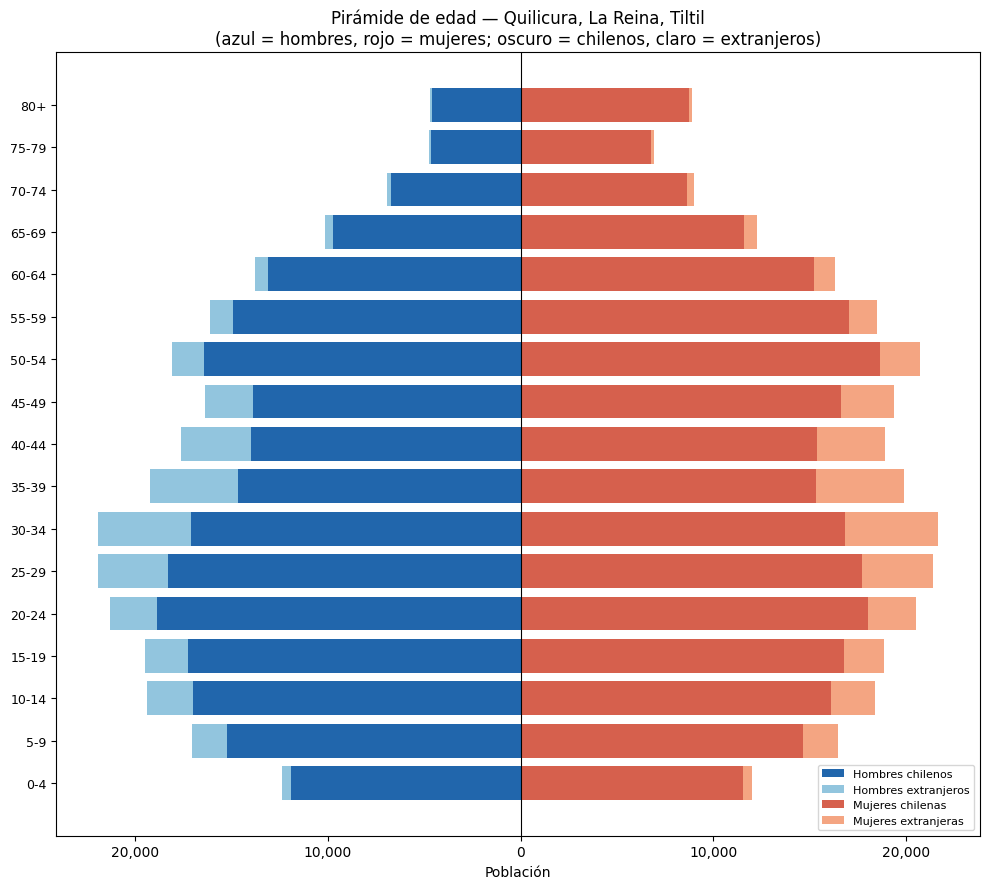

In [65]:
# Mapeo de nacionalidad recodificada
NAC_MAP = {1: "Chile", 2: "Extranjero", -99: np.nan}
df["nacimiento"] = df["p25_lug_nacimiento_rec"].map(NAC_MAP)

# Filtrar edades inválidas (-99 = missing)
df_edad = df[df["edad"] >= 0].copy()

# Crear bins de edad de 5 años
bins   = list(range(0, 81, 5)) + [200]
labels = [f"{i}-{i+4}" for i in range(0, 80, 5)] + ["80+"]
df_edad["age_group"] = pd.cut(df_edad["edad"], bins=bins, labels=labels, right=False)

# Contar por sexo, grupo etario y nacionalidad
pyr = (df_edad.groupby(["age_group", "sexo", "nacimiento"], observed=True)
.size().reset_index(name="n"))

# Separar hombres (sexo=1) y mujeres (sexo=2)
males   = pyr[pyr["sexo"] == 1].copy()
females = pyr[pyr["sexo"] == 2].copy()

# Pivotar para tener chilenos y extranjeros por separado
def pivot_pyr(df_sex):
    d = df_sex.pivot_table(index="age_group", columns="nacimiento",
    values="n", aggfunc="sum", observed=True).fillna(0)
    for c in ["Chile", "Extranjero"]:
        if c not in d.columns:
            d[c] = 0
    return d

m = pivot_pyr(males)
f = pivot_pyr(females)

fig, ax = plt.subplots(figsize=(10, 9))
y = range(len(labels))

# Hombres (izquierda, negativos)
ax.barh(list(y), -m["Chile"],  color="#2166ac", label="Hombres chilenos")
ax.barh(list(y), -m["Extranjero"], left=-m["Chile"], # Changed 'Chilena' to 'Chile' and 'Extranjera' to 'Extranjero' to match NAC_MAP
        color="#92c5de", label="Hombres extranjeros")

# Mujeres (derecha, positivos)
ax.barh(list(y), f["Chile"],  color="#d6604d", label="Mujeres chilenas")
ax.barh(list(y), f["Extranjero"], left=f["Chile"], # Changed 'Chilena' to 'Chile' and 'Extranjera' to 'Extranjero' to match NAC_MAP
        color="#f4a582", label="Mujeres extranjeras")

ax.set_yticks(list(y))
ax.set_yticklabels(labels, fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{abs(int(x)):,}"))
ax.set_xlabel("Población")
ax.set_title("Pirámide de edad — Quilicura, La Reina, Tiltil\n(azul = hombres, rojo = mujeres; oscuro = chilenos, claro = extranjeros)")
ax.axvline(0, color="black", linewidth=0.8)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

### 1.2 Razón de dependencia por comuna

La razón de dependencia mide cuántas personas dependientes (menores de 15 y mayores de 64) hay por cada persona en edad de trabajar (15–64). Un valor alto indica mayor presión sobre la población activa.

Se excluyen edades con valor -99 (missing).

In [66]:
dep_rows = []
for cod, nombre in zip([13122, 13109, 13125], ["Quilicura", "La Reina", "Tiltil"]):
    sub = df_edad[df_edad["codigo_comuna"] == cod]
    dep   = len(sub[(sub["edad"] < 15) | (sub["edad"] >= 65)])
    activ = len(sub[(sub["edad"] >= 15) & (sub["edad"] < 65)])
    ratio = dep / activ if activ > 0 else np.nan
    dep_rows.append({"Comuna": nombre, "Dependientes (0-14 y 65+)": dep,
                     "Activos (15-64)": activ, "Razón de dependencia": round(ratio, 3)})

dep_df = pd.DataFrame(dep_rows)
print(dep_df.to_string(index=False))

   Comuna  Dependientes (0-14 y 65+)  Activos (15-64)  Razón de dependencia
Quilicura                      71677           164801                 0.435
 La Reina                      31913            71244                 0.448
   Tiltil                      57161           148463                 0.385


**Interpretación:** Las tres comunas presentan razones de dependencia moderadas (entre 0.385 y 0.448), por debajo del promedio nacional típico (~0.50). Esto refleja una población predominantemente en edad activa, lo cual es consistente con el perfil de comunas que atraen inmigración laboral.

- **La Reina (0.448)** tiene la razón más alta, coherente con su perfil socioeconómico alto y mayor proporción de adultos mayores.
- **Quilicura (0.435)** refleja una población joven y de alta migración laboral.
- **Tiltil (0.385)** tiene la razón más baja, lo que puede indicar una estructura más joven o mayor proporción de personas en edad laboral, posiblemente por atracción de trabajadores inmigrantes en el sector rural-periurbano.


### 1.3 Distribución del tamaño de hogar

Calculamos el número de personas por hogar usando `id_vivienda` e `id_hogar`. Visualizamos la distribución agrupando los hogares de 8 o más personas en un solo bin `8+`. También comparamos si hay diferencias entre hogares con jefe chileno vs. extranjero.

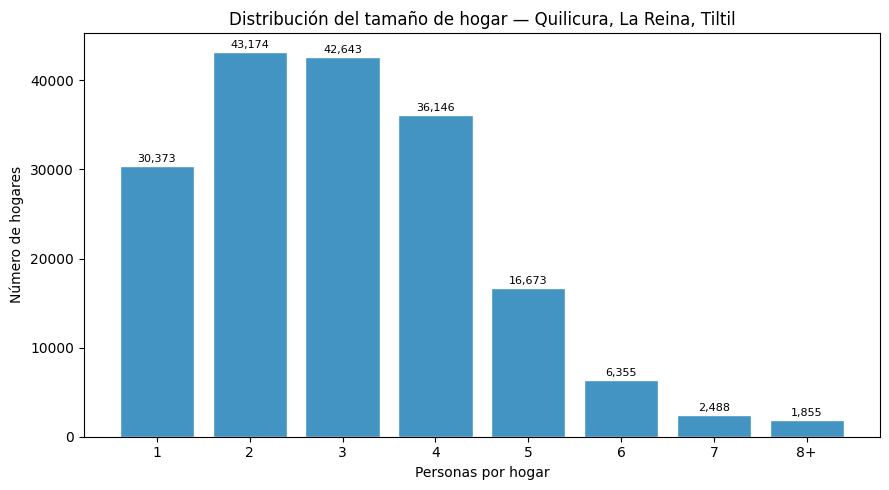

Tamaño de hogar promedio: 3.03 personas
Tamaño de hogar mediano:  3 personas


In [67]:
# Tamaño de hogar: personas por (id_vivienda, id_hogar)
hhsize = (df.groupby(["id_vivienda", "id_hogar", "codigo_comuna"])
            .size().reset_index(name="hh_size"))

# Agrupar 8+ en un solo bin
hhsize["hh_size_cat"] = hhsize["hh_size"].clip(upper=8)
hhsize["hh_size_label"] = hhsize["hh_size_cat"].apply(lambda x: "8+" if x == 8 else str(x))

dist = (hhsize.groupby("hh_size_label")["id_vivienda"]
              .count().reindex(["1","2","3","4","5","6","7","8+"], fill_value=0))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(dist.index, dist.values, color="#4393c3", edgecolor="white")
ax.set_xlabel("Personas por hogar")
ax.set_ylabel("Número de hogares")
ax.set_title("Distribución del tamaño de hogar — Quilicura, La Reina, Tiltil")
for i, v in enumerate(dist.values):
    ax.text(i, v + dist.values.max()*0.01, f"{v:,}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

print(f"Tamaño de hogar promedio: {hhsize['hh_size'].mean():.2f} personas")
print(f"Tamaño de hogar mediano:  {hhsize['hh_size'].median():.0f} personas")

### 1.4 Educación y empleo por comuna y nacionalidad

Calculamos dos indicadores clave para la población de cada comuna:

1. **Años de escolaridad promedio** (`escolaridad`) para personas de 25 años o más, separado por chilenos y extranjeros. Se excluyen valores -99.
2. **Tasa de empleo** (`sit_fuerza_trabajo == 1`) para personas de 15 a 64 años. Se excluyen valores -99.

Presentamos los resultados como gráfico de barras agrupadas.

   Comuna  Esc. Chilenos  Esc. Extranjeros  Emp. Chilenos  Emp. Extranjeros
Quilicura          12.19             13.06          0.646             0.778
 La Reina          12.91             13.56          0.675             0.789
   Tiltil          12.17             12.35          0.621             0.740


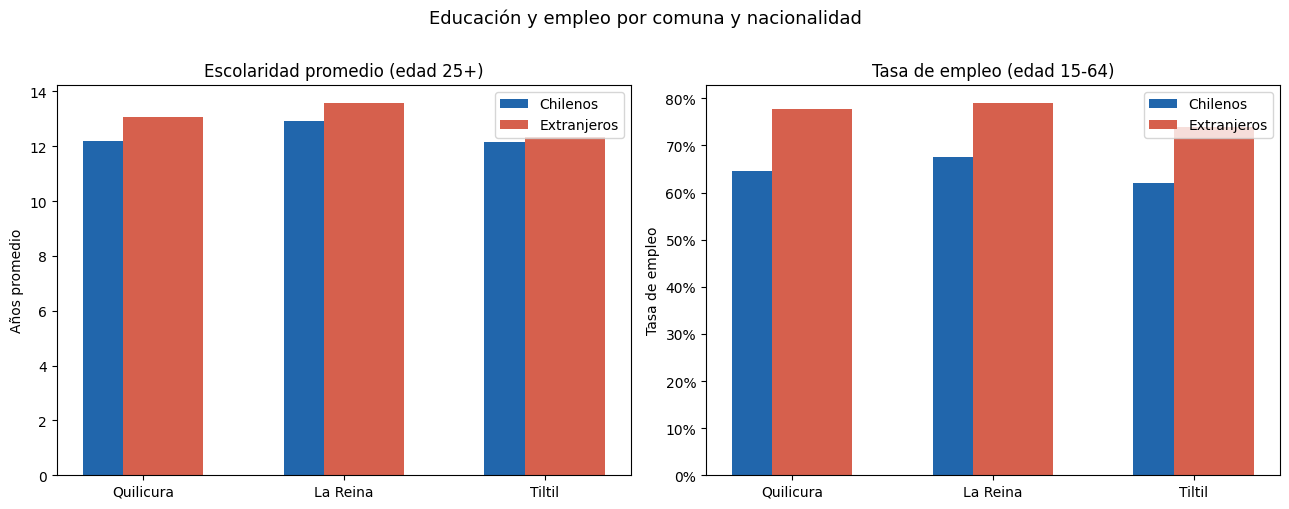

In [68]:
COMUNA_NOMBRES = {13122: "Quilicura", 13109: "La Reina", 13125: "Tiltil"}

edu_emp = []
for cod, nombre in COMUNA_NOMBRES.items():
    sub = df[df["codigo_comuna"] == cod].copy()

    # Escolaridad: edad >= 25, excluir -99
    esc = sub[(sub["edad"] >= 25) & (sub["escolaridad"] >= 0)]
    esc_cl = esc[esc["p25_lug_nacimiento_rec"] == 1]["escolaridad"].mean()
    esc_ex = esc[esc["p25_lug_nacimiento_rec"] == 2]["escolaridad"].mean()

    # Empleo: edad 15-64, excluir -99
    emp = sub[(sub["edad"] >= 15) & (sub["edad"] <= 64) & (sub["sit_fuerza_trabajo"] >= 0)]
    emp_cl_sub = emp[emp["p25_lug_nacimiento_rec"] == 1]
    emp_ex_sub = emp[emp["p25_lug_nacimiento_rec"] == 2]
    emp_rate_cl = (emp_cl_sub["sit_fuerza_trabajo"] == 1).mean()
    emp_rate_ex = (emp_ex_sub["sit_fuerza_trabajo"] == 1).mean()

    edu_emp.append({"Comuna": nombre,
                    "Esc. Chilenos": round(esc_cl, 2),
                    "Esc. Extranjeros": round(esc_ex, 2),
                    "Emp. Chilenos": round(emp_rate_cl, 3),
                    "Emp. Extranjeros": round(emp_rate_ex, 3)})

edu_df = pd.DataFrame(edu_emp)
print(edu_df.to_string(index=False))

# Gráfico agrupado
x = np.arange(len(edu_df))
w = 0.2
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Escolaridad
axes[0].bar(x - w/2, edu_df["Esc. Chilenos"],  w*2, label="Chilenos",   color="#2166ac")
axes[0].bar(x + w/2, edu_df["Esc. Extranjeros"], w*2, label="Extranjeros", color="#d6604d")
axes[0].set_xticks(x); axes[0].set_xticklabels(edu_df["Comuna"])
axes[0].set_ylabel("Años promedio"); axes[0].set_title("Escolaridad promedio (edad 25+)")
axes[0].legend()

# Empleo
axes[1].bar(x - w/2, edu_df["Emp. Chilenos"],    w*2, label="Chilenos",   color="#2166ac")
axes[1].bar(x + w/2, edu_df["Emp. Extranjeros"], w*2, label="Extranjeros", color="#d6604d")
axes[1].set_xticks(x); axes[1].set_xticklabels(edu_df["Comuna"])
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_ylabel("Tasa de empleo"); axes[1].set_title("Tasa de empleo (edad 15-64)")
axes[1].legend()

plt.suptitle("Educación y empleo por comuna y nacionalidad", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Parte 2: Paisaje Migratorio

Analizamos en profundidad las características migratorias de las tres comunas: porcentaje de extranjeros, principales nacionalidades, movilidad residencial y períodos de llegada.

### 2.1 Porcentaje de extranjeros por comuna

Para cada comuna calculamos qué fracción de la población ha nacido en el extranjero según `p25_lug_nacimiento_rec`. Presentamos los resultados como tabla y gráfico de barras.

   Comuna  Población total  Extranjeros  % Extranjeros
Quilicura           234911        20141           8.57
 La Reina           101971        19762          19.38
   Tiltil           204408        27310          13.36


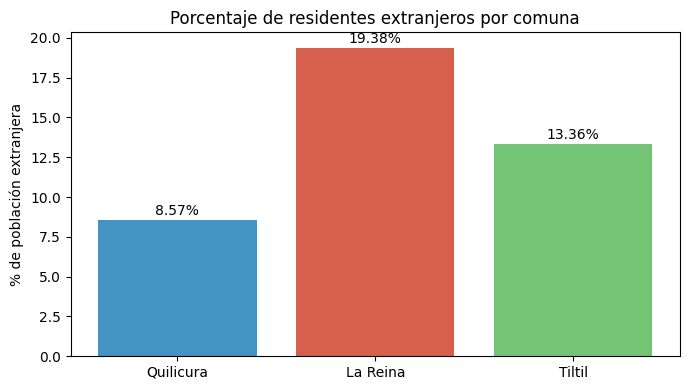

In [69]:
pct_rows = []
for cod, nombre in COMUNA_NOMBRES.items():
    sub = df[(df["codigo_comuna"] == cod) & (df["p25_lug_nacimiento_rec"].isin([1, 2]))]
    total   = len(sub)
    foreign = (sub["p25_lug_nacimiento_rec"] == 2).sum()
    pct_rows.append({"Comuna": nombre, "Población total": total,
                     "Extranjeros": foreign,
                     "% Extranjeros": round(100 * foreign / total, 2)})

pct_df = pd.DataFrame(pct_rows)
print(pct_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(pct_df["Comuna"], pct_df["% Extranjeros"], color=["#4393c3","#d6604d","#74c476"])
for i, v in enumerate(pct_df["% Extranjeros"]):
    ax.text(i, v + 0.3, f"{v}%", ha="center", fontsize=10)
ax.set_ylabel("% de población extranjera")
ax.set_title("Porcentaje de residentes extranjeros por comuna")
plt.tight_layout()
plt.show()

### 2.2 Top 10 países de nacimiento entre extranjeros

Usamos `p25_lug_nacimiento_esp` para identificar los 10 países de nacimiento más frecuentes entre los residentes extranjeros. Esta variable contiene códigos territoriales específicos por país, a diferencia de `p27_nacionalidad` y `p25_lug_nacimiento` que registran categorías genéricas en el microdato público del Censo 2024.

In [70]:
# Paso 1: Ver los códigos reales de lugar de nacimiento entre extranjeros
# Usamos p25_lug_nacimiento_esp que contiene el código específico del país de nacimiento.
extranjeros_raw = df[df["p25_lug_nacimiento_rec"] == 2].copy()
print("Códigos de lugar de nacimiento (p25_lug_nacimiento_esp) más frecuentes entre extranjeros:")
print(extranjeros_raw["p25_lug_nacimiento_esp"].value_counts().head(20))


Códigos de lugar de nacimiento (p25_lug_nacimiento_esp) más frecuentes entre extranjeros:
p25_lug_nacimiento_esp
 862    30366
 604    11788
 332     9183
 170     6890
 5       2872
 32      1979
 13      1414
 68      1200
 150      725
 142      434
 21       254
-99        43
 9         38
 2         27
Name: count, dtype: int64


Códigos aún sin mapear:
p25_lug_nacimiento_esp
9    38
Name: count, dtype: int64

Top 10 países de nacimiento:
pais
Venezuela                            30366
Perú                                 11788
Haití                                 9183
Colombia                              6890
Sudamérica (sin especificar)          2872
Argentina                             1979
América Central (sin especificar)     1414
Bolivia                               1200
Europa (sin especificar)               725
Asia (sin especificar)                 434
Name: count, dtype: int64


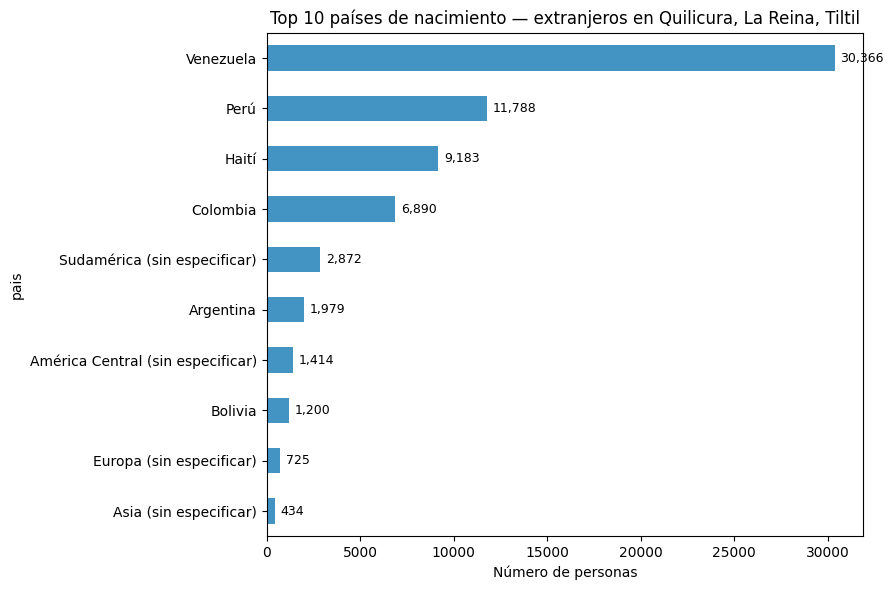

In [71]:
# Paso 2: Mapeo de códigos de p25_lug_nacimiento_esp a países
# Esta variable usa ISO 3166-1 numérico y códigos regionales M.49 de la ONU.
# Códigos de comunas chilenas (ej. 13122, 13109, 13125) que aparecen aquí
# corresponden a personas nacidas en Chile → se excluyen del análisis de extranjeros.
LUG_NAC_ESP = {
    4:   "Afganistán",
    8:   "Albania",
    12:  "Argelia",
    24:  "Angola",
    32:  "Argentina",
    50:  "Bangladesh",
    68:  "Bolivia",
    76:  "Brasil",
    116: "Camboya",
    144: "Sri Lanka",
    152: "Chile",
    156: "China",
    170: "Colombia",
    188: "Costa Rica",
    192: "Cuba",
    214: "Rep. Dominicana",
    218: "Ecuador",
    222: "El Salvador",
    231: "Etiopía",
    250: "Francia",
    276: "Alemania",
    320: "Guatemala",
    332: "Haití",
    340: "Honduras",
    356: "India",
    364: "Irán",
    380: "Italia",
    388: "Jamaica",
    400: "Jordania",
    408: "Corea del Norte",
    410: "Corea del Sur",
    422: "Líbano",
    484: "México",
    504: "Marruecos",
    524: "Nepal",
    558: "Nicaragua",
    566: "Nigeria",
    586: "Pakistán",
    591: "Panamá",
    598: "Papua Nueva Guinea",
    600: "Paraguay",
    604: "Perú",
    608: "Filipinas",
    630: "Puerto Rico",
    703: "Eslovaquia",
    710: "Sudáfrica",
    716: "Zimbabue",
    724: "España",
    756: "Suiza",
    760: "Siria",
    764: "Tailandia",
    788: "Túnez",
    804: "Ucrania",
    826: "Reino Unido",
    840: "Estados Unidos",
    858: "Uruguay",
    862: "Venezuela",
    # Códigos regionales M.49 ONU (agrupaciones)
    5:   "Sudamérica (sin especificar)",
    13:  "América Central (sin especificar)",
    21:  "América del Norte (sin especificar)",
    142: "Asia (sin especificar)",
    150: "Europa (sin especificar)",
    2:   "África (sin especificar)",
    # Valores especiales
    -99: "No respuesta",
    -66: "Valor suprimido",
}

# Códigos de comunas chilenas que pueden aparecer en p25_lug_nacimiento_esp
# (personas marcadas como extranjeras pero con código de comuna → inconsistencia censal)
CODIGOS_COMUNAS_CL = {13122, 13109, 13125, 13101, 13108, 13119, 13120}

extranjeros = df[df["p25_lug_nacimiento_rec"] == 2].copy()
# Excluir filas con códigos de comunas chilenas (inconsistencia en los datos)
extranjeros = extranjeros[~extranjeros["p25_lug_nacimiento_esp"].isin(CODIGOS_COMUNAS_CL)]
extranjeros["pais"] = extranjeros["p25_lug_nacimiento_esp"].map(LUG_NAC_ESP).fillna("Otro")

# Verificar códigos sin mapear
unmapped = extranjeros[extranjeros["pais"] == "Otro"]["p25_lug_nacimiento_esp"].value_counts().head(10)
if len(unmapped) > 0:
    print("Códigos aún sin mapear:")
    print(unmapped)
else:
    print("✓ Todos los códigos relevantes están mapeados.")

top10 = (extranjeros[~extranjeros["pais"].isin(["No respuesta", "Valor suprimido", "Chile"])]
         ["pais"].value_counts().head(10))
print("\nTop 10 países de nacimiento:")
print(top10)

fig, ax = plt.subplots(figsize=(9, 6))
top10.sort_values().plot(kind="barh", ax=ax, color="#4393c3")
ax.set_xlabel("Número de personas")
ax.set_title("Top 10 países de nacimiento — extranjeros en Quilicura, La Reina, Tiltil")
for i, v in enumerate(top10.sort_values()):
    ax.text(v + top10.max()*0.01, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


### 2.3 Movilidad residencial: ¿dónde vivían hace 5 años?

La variable `p24_lug_resid5` indica dónde vivía cada persona 5 años antes del Censo. Filtramos personas menores de 5 años (que no estaban vivas o no aplica) y los valores -99. Calculamos el porcentaje por categoría para cada comuna y lo presentamos como gráfico de barras apiladas.

Valores únicos de p24_lug_resid5:
p24_lug_resid5
-99      4528
 1      24635
 2     417134
 3      76394
 4      22568
Name: count, dtype: int64

Distribución de residencia hace 5 años (%):

           Misma comuna  Otra comuna, misma región  Otra región  Otro país
Quilicura         84.21                      12.75         3.04        0.0
La Reina          65.52                      25.76         8.72        0.0
Tiltil            84.57                      11.68         3.74        0.0


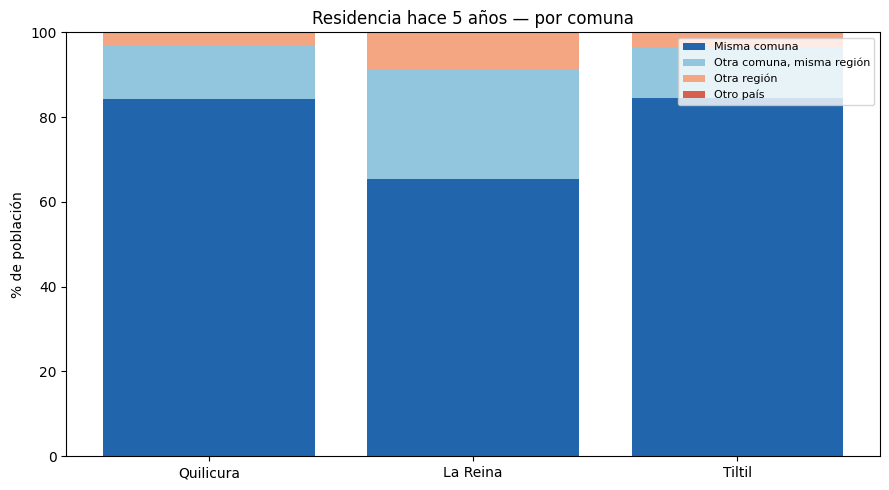

In [72]:
# Diagnóstico: valores reales de p24_lug_resid5
print("Valores únicos de p24_lug_resid5:")
print(df["p24_lug_resid5"].value_counts().sort_index())

# Mapeo corregido según diccionario Censo 2024:
# 1 = Esta misma vivienda (misma comuna)
# 2 = Otra vivienda, misma comuna
# 3 = Otra comuna, misma región
# 4 = Otra región de Chile
# 5 = Otro país
# -99 = No responde / No aplica
RESID5_MAP = {
    1: "Misma comuna",
    2: "Misma comuna",
    3: "Otra comuna, misma región",
    4: "Otra región",
    5: "Otro país",
    -99: np.nan
}

df_r5 = df[(df["edad"] >= 5) & (df["p24_lug_resid5"].isin([1, 2, 3, 4, 5]))].copy()
df_r5["resid5"] = df_r5["p24_lug_resid5"].map(RESID5_MAP)

cats = ["Misma comuna", "Otra comuna, misma región", "Otra región", "Otro país"]
stacked = {}
for cod, nombre in COMUNA_NOMBRES.items():
    sub = df_r5[df_r5["codigo_comuna"] == cod]
    total = len(sub)
    stacked[nombre] = {c: round(100 * (sub["resid5"] == c).sum() / total, 2)
                       for c in cats}

stack_df = pd.DataFrame(stacked).T
print("\nDistribución de residencia hace 5 años (%):\n")
print(stack_df)

colors = ["#2166ac", "#92c5de", "#f4a582", "#d6604d"]
fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(stack_df))
for col, color in zip(cats, colors):
    ax.bar(stack_df.index, stack_df[col], bottom=bottom, label=col, color=color)
    bottom += stack_df[col].values

ax.set_ylabel("% de población")
ax.set_title("Residencia hace 5 años — por comuna")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


### 2.4 Período de llegada de inmigrantes

Usamos `p26_llegada_periodo` para ver cuándo llegaron a Chile los residentes extranjeros. Esto permite determinar si la inmigración es un fenómeno reciente o tiene una historia más larga en nuestras comunas.

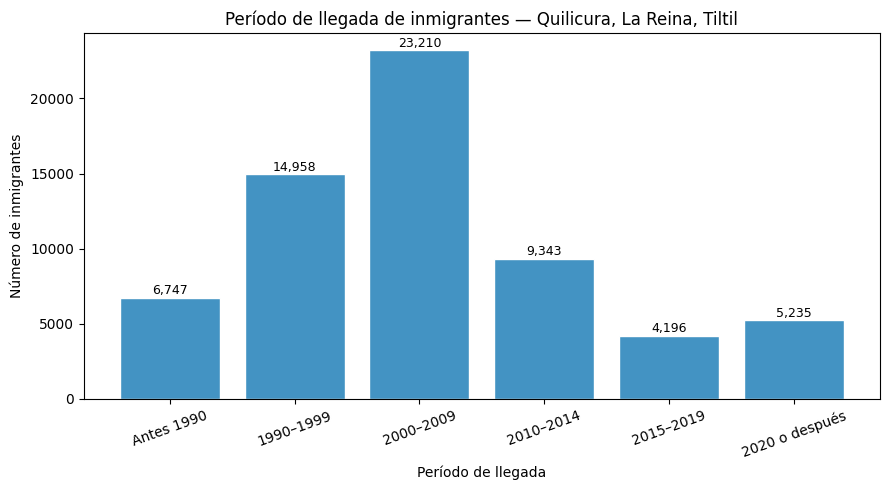


Distribución porcentual por período:
periodo
Antes 1990        10.6
1990–1999         23.5
2000–2009         36.4
2010–2014         14.7
2015–2019          6.6
2020 o después     8.2


In [73]:
LLEGADA_MAP = {
    1: "Antes 1990",
    2: "1990–1999",
    3: "2000–2009",
    4: "2010–2014",
    5: "2015–2019",
    6: "2020 o después",
    -99: np.nan
}

inmigrantes = df[(df["p25_lug_nacimiento_rec"] == 2) &
                 (df["p26_llegada_periodo"].isin(LLEGADA_MAP.keys())) &
                 (df["p26_llegada_periodo"] != -99)].copy()
inmigrantes["periodo"] = inmigrantes["p26_llegada_periodo"].map(LLEGADA_MAP)

orden = ["Antes 1990","1990–1999","2000–2009","2010–2014","2015–2019","2020 o después"]
dist_lleg = inmigrantes["periodo"].value_counts().reindex(orden, fill_value=0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(dist_lleg.index, dist_lleg.values, color="#4393c3", edgecolor="white")
ax.set_xlabel("Período de llegada")
ax.set_ylabel("Número de inmigrantes")
ax.set_title("Período de llegada de inmigrantes — Quilicura, La Reina, Tiltil")
plt.xticks(rotation=20)
for i, v in enumerate(dist_lleg.values):
    ax.text(i, v + dist_lleg.max()*0.01, f"{v:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("\nDistribución porcentual por período:")
print((dist_lleg / dist_lleg.sum() * 100).round(1).to_string())

**Interpretación:** Los datos muestran que el período 2000–2009 concentra el mayor flujo inmigratorio hacia estas comunas (~37% del total), lo que indica que la inmigración **no es un fenómeno exclusivamente reciente** sino que tiene raíces históricas desde los 2000s. Esto coincide con las primeras olas migratorias latinoamericanas hacia Chile, impulsadas principalmente por inmigración peruana y boliviana.

Sin embargo, al observar los períodos 2015–2019 y 2020 en adelante (~13% combinado), se evidencia también una ola migratoria más reciente, asociada a la llegada masiva de venezolanos, haitianos y colombianos. La combinación de ambas olas explica la diversidad de nacionalidades observada en la Parte 2.2, donde Venezuela lidera el total pero Perú y Haití también tienen presencia significativa.

Tiltil, a pesar de ser una comuna rural, muestra una proporción notable de inmigrantes recientes, lo que puede estar relacionado con trabajo agrícola y acceso a vivienda más económica en la periferia metropolitana.


---
## Parte 3: Visualización Espacial

Creamos dos mapas coropléticos usando `geopandas` con el shapefile oficial de comunas chilenas. El primero muestra la población total por comuna y el segundo el porcentaje de extranjeros.

### 3.1 Mapa coroplético: población total por comuna

Comunas en el mapa: ['La Reina', 'Quilicura', 'Tiltil']
Población: {'La Reina': 103157, 'Quilicura': 236478, 'Tiltil': 205624}


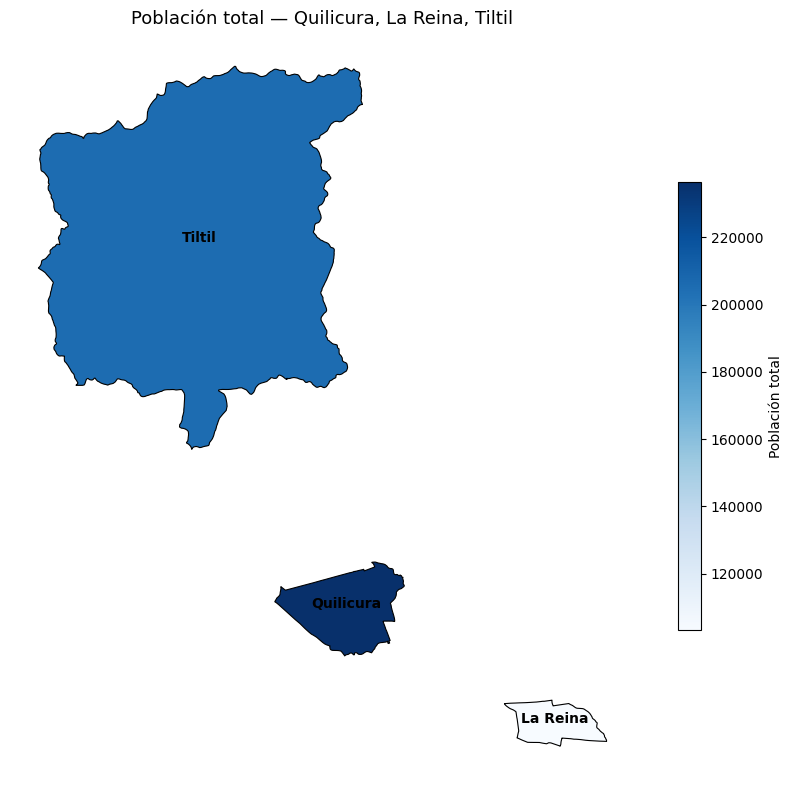

In [74]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Cargar shapefile de comunas
comunas_gdf = gpd.read_file("comunas.shp")
comunas_gdf["cod_comuna"] = pd.to_numeric(comunas_gdf["cod_comuna"], errors="coerce")

# IMPORTANTE: Los códigos en el shapefile difieren de los del Censo.
# Códigos correctos según el shapefile para nuestras comunas:
#   Quilicura → 13125, La Reina → 13113, Tiltil → 13303
SHP_COMUNAS = [13125, 13113, 13303]
CODIGO_A_NOMBRE = {13122: "Quilicura", 13109: "La Reina", 13125: "Tiltil"}

# Población total usando códigos del Censo (df)
pop_total = df.groupby("codigo_comuna").size().reset_index(name="pop_total")

# Mapear códigos Censo → códigos shapefile para el merge
CENSO_A_SHP = {13122: 13125, 13109: 13113, 13125: 13303}
pop_total["cod_comuna"] = pop_total["codigo_comuna"].map(CENSO_A_SHP)

# Filtrar shapefile y hacer merge
gdf = comunas_gdf[comunas_gdf["cod_comuna"].isin(SHP_COMUNAS)].merge(
    pop_total, on="cod_comuna", how="left")

print(f"Comunas en el mapa: {gdf['Comuna'].tolist()}")
print(f"Población: {dict(zip(gdf['Comuna'], gdf['pop_total']))}")

fig, ax = plt.subplots(figsize=(9, 8))
gdf.plot(column="pop_total", ax=ax, legend=True,
         legend_kwds={"label": "Población total", "shrink": 0.6},
         cmap="Blues", edgecolor="black", linewidth=0.8)

for _, row in gdf.iterrows():
    try:
        centroid = row.geometry.centroid
        ax.annotate(row["Comuna"], xy=(centroid.x, centroid.y),
                    ha="center", fontsize=10, fontweight="bold", color="black")
    except:
        pass

ax.set_title("Población total — Quilicura, La Reina, Tiltil", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()


### 3.2 Mapa coroplético: % de extranjeros por comuna

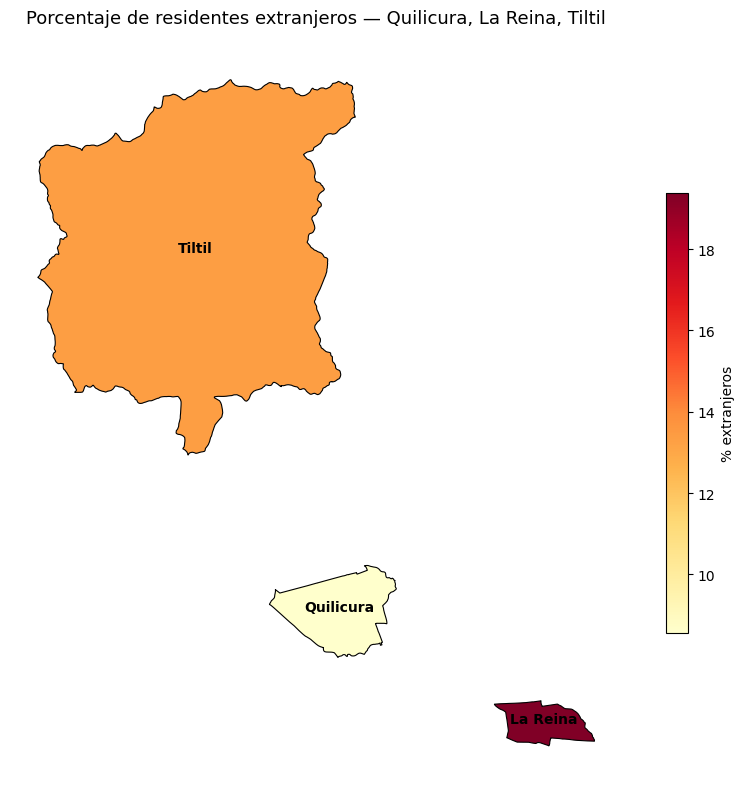

In [75]:
import geopandas as gpd

# % extranjeros por comuna usando códigos del Censo
pct_ext = (df[df["p25_lug_nacimiento_rec"].isin([1, 2])]
           .groupby("codigo_comuna")
           .apply(lambda x: 100 * (x["p25_lug_nacimiento_rec"] == 2).sum() / len(x))
           .reset_index(name="pct_foreign"))

# Mapear códigos Censo → códigos shapefile
CENSO_A_SHP = {13122: 13125, 13109: 13113, 13125: 13303}
pct_ext["cod_comuna"] = pct_ext["codigo_comuna"].map(CENSO_A_SHP)

SHP_COMUNAS = [13125, 13113, 13303]
gdf2 = comunas_gdf[comunas_gdf["cod_comuna"].isin(SHP_COMUNAS)].merge(
    pct_ext, on="cod_comuna", how="left")

fig, ax = plt.subplots(figsize=(9, 8))
gdf2.plot(column="pct_foreign", ax=ax, legend=True,
          legend_kwds={"label": "% extranjeros", "shrink": 0.6},
          cmap="YlOrRd", edgecolor="black", linewidth=0.8)

for _, row in gdf2.iterrows():
    try:
        centroid = row.geometry.centroid
        ax.annotate(row["Comuna"], xy=(centroid.x, centroid.y),
                    ha="center", fontsize=10, fontweight="bold", color="black")
    except:
        pass

ax.set_title("Porcentaje de residentes extranjeros — Quilicura, La Reina, Tiltil", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

In [76]:
# Join persona → hogar → vivienda
df = per.merge(hog, on=["id_vivienda", "id_hogar"], how="left")         .merge(viv, on="id_vivienda", how="left")

# Verificación de integridad
assert len(df) == len(per), "¡Error: el join modificó el número de filas!"
print("✓ Join exitoso — el número de filas se mantiene igual.")
print(f"df.shape: {df.shape}")
df.info()

✓ Join exitoso — el número de filas se mantiene igual.
df.shape: (545259, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545259 entries, 0 to 545258
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id_vivienda             545259 non-null  int32  
 1   id_hogar                545259 non-null  int32  
 2   id_persona              545259 non-null  int32  
 3   sexo                    545259 non-null  int32  
 4   edad                    545259 non-null  int32  
 5   p27_nacionalidad        545259 non-null  int32  
 6   p27_nacionalidad_rec    545259 non-null  int32  
 7   p24_lug_resid5          545259 non-null  int32  
 8   p25_lug_nacimiento      545259 non-null  int32  
 9   p25_lug_nacimiento_esp  545259 non-null  int32  
 10  p25_lug_nacimiento_rec  545259 non-null  int32  
 11  p26_llegada_periodo     67213 non-null   float64
 12  escolaridad             545259 non-null  int32  
 

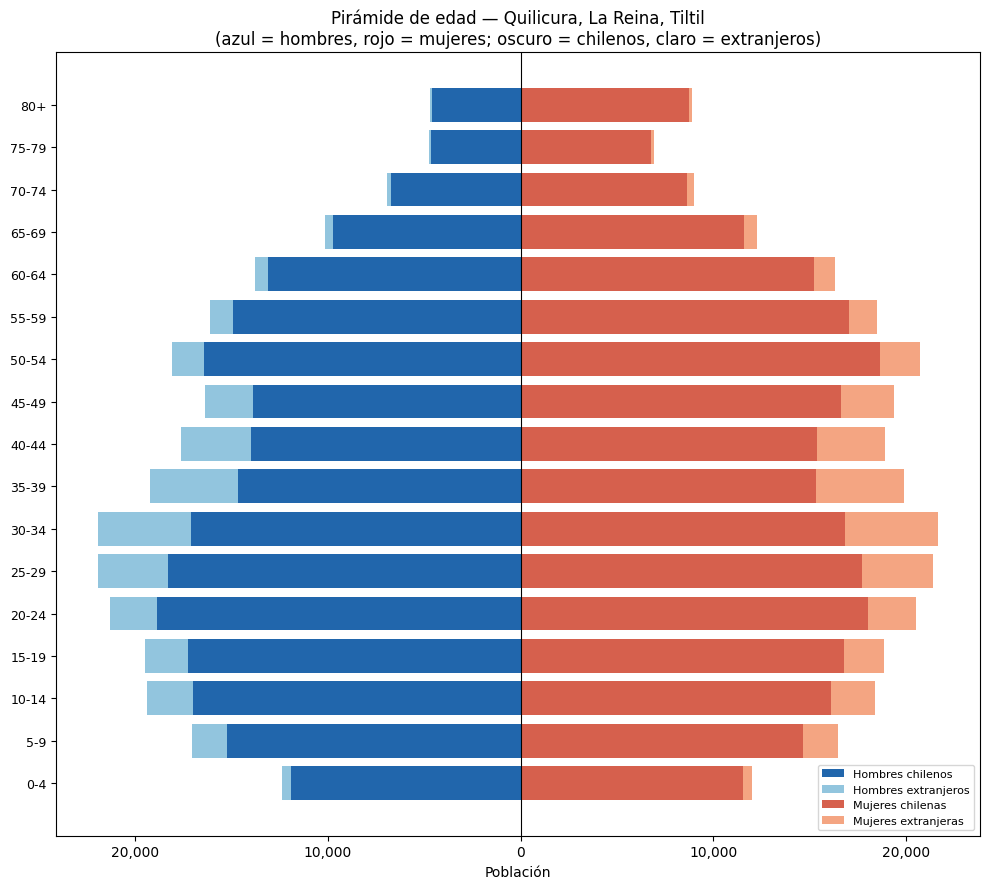

In [77]:
# Mapeo de nacionalidad recodificada
NAC_MAP = {1: "Chile", 2: "Extranjero", -99: np.nan}
df["nacimiento"] = df["p25_lug_nacimiento_rec"].map(NAC_MAP)

# Filtrar edades inválidas (-99 = missing)
df_edad = df[df["edad"] >= 0].copy()

# Crear bins de edad de 5 años
bins   = list(range(0, 81, 5)) + [200]
labels = [f"{i}-{i+4}" for i in range(0, 80, 5)] + ["80+"]
df_edad["age_group"] = pd.cut(df_edad["edad"], bins=bins, labels=labels, right=False)

# Contar por sexo, grupo etario y nacionalidad
pyr = (df_edad.groupby(["age_group", "sexo", "nacimiento"], observed=True)
.size().reset_index(name="n"))

# Separar hombres (sexo=1) y mujeres (sexo=2)
males   = pyr[pyr["sexo"] == 1].copy()
females = pyr[pyr["sexo"] == 2].copy()

# Pivotar para tener chilenos y extranjeros por separado
def pivot_pyr(df_sex):
    d = df_sex.pivot_table(index="age_group", columns="nacimiento",
    values="n", aggfunc="sum", observed=True).fillna(0)
    for c in ["Chile", "Extranjero"]:
        if c not in d.columns:
            d[c] = 0
    return d

m = pivot_pyr(males)
f = pivot_pyr(females)

fig, ax = plt.subplots(figsize=(10, 9))
y = range(len(labels))

# Hombres (izquierda, negativos)
ax.barh(list(y), -m["Chile"],  color="#2166ac", label="Hombres chilenos")
ax.barh(list(y), -m["Extranjero"], left=-m["Chile"], # Changed 'Chilena' to 'Chile' and 'Extranjera' to 'Extranjero' to match NAC_MAP
        color="#92c5de", label="Hombres extranjeros")

# Mujeres (derecha, positivos)
ax.barh(list(y), f["Chile"],  color="#d6604d", label="Mujeres chilenas")
ax.barh(list(y), f["Extranjero"], left=f["Chile"], # Changed 'Chilena' to 'Chile' and 'Extranjera' to 'Extranjero' to match NAC_MAP
        color="#f4a582", label="Mujeres extranjeras")

ax.set_yticks(list(y))
ax.set_yticklabels(labels, fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{abs(int(x)):,}"))
ax.set_xlabel("Población")
ax.set_title("Pirámide de edad — Quilicura, La Reina, Tiltil\n(azul = hombres, rojo = mujeres; oscuro = chilenos, claro = extranjeros)")
ax.axvline(0, color="black", linewidth=0.8)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

In [78]:
dep_rows = []
for cod, nombre in zip([13122, 13109, 13125], ["Quilicura", "La Reina", "Tiltil"]):
    sub = df_edad[df_edad["codigo_comuna"] == cod]
    dep   = len(sub[(sub["edad"] < 15) | (sub["edad"] >= 65)])
    activ = len(sub[(sub["edad"] >= 15) & (sub["edad"] < 65)])
    ratio = dep / activ if activ > 0 else np.nan
    dep_rows.append({"Comuna": nombre, "Dependientes (0-14 y 65+)": dep,
                     "Activos (15-64)": activ, "Razón de dependencia": round(ratio, 3)})

dep_df = pd.DataFrame(dep_rows)
print(dep_df.to_string(index=False))

   Comuna  Dependientes (0-14 y 65+)  Activos (15-64)  Razón de dependencia
Quilicura                      71677           164801                 0.435
 La Reina                      31913            71244                 0.448
   Tiltil                      57161           148463                 0.385


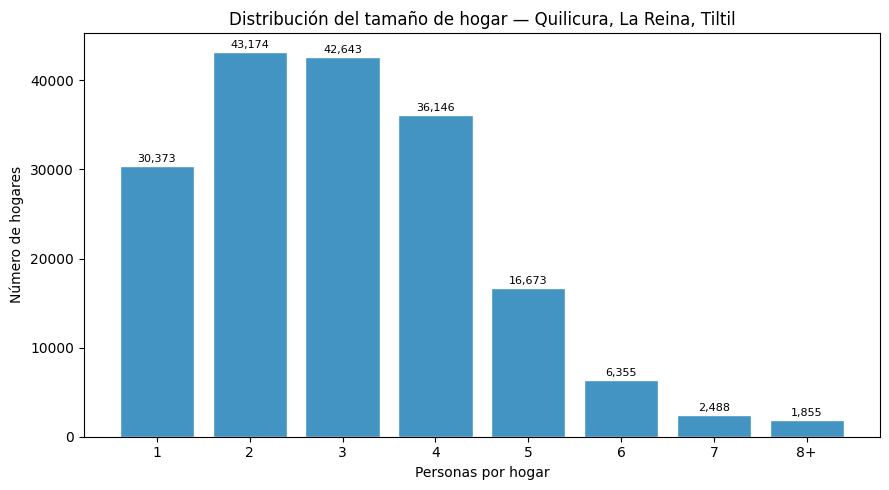

Tamaño de hogar promedio: 3.03 personas
Tamaño de hogar mediano:  3 personas


In [79]:
# Tamaño de hogar: personas por (id_vivienda, id_hogar)
hhsize = (df.groupby(["id_vivienda", "id_hogar", "codigo_comuna"])
            .size().reset_index(name="hh_size"))

# Agrupar 8+ en un solo bin
hhsize["hh_size_cat"] = hhsize["hh_size"].clip(upper=8)
hhsize["hh_size_label"] = hhsize["hh_size_cat"].apply(lambda x: "8+" if x == 8 else str(x))

dist = (hhsize.groupby("hh_size_label")["id_vivienda"]
              .count().reindex(["1","2","3","4","5","6","7","8+"], fill_value=0))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(dist.index, dist.values, color="#4393c3", edgecolor="white")
ax.set_xlabel("Personas por hogar")
ax.set_ylabel("Número de hogares")
ax.set_title("Distribución del tamaño de hogar — Quilicura, La Reina, Tiltil")
for i, v in enumerate(dist.values):
    ax.text(i, v + dist.values.max()*0.01, f"{v:,}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

print(f"Tamaño de hogar promedio: {hhsize['hh_size'].mean():.2f} personas")
print(f"Tamaño de hogar mediano:  {hhsize['hh_size'].median():.0f} personas")

   Comuna  Esc. Chilenos  Esc. Extranjeros  Emp. Chilenos  Emp. Extranjeros
Quilicura          12.19             13.06          0.646             0.778
 La Reina          12.91             13.56          0.675             0.789
   Tiltil          12.17             12.35          0.621             0.740


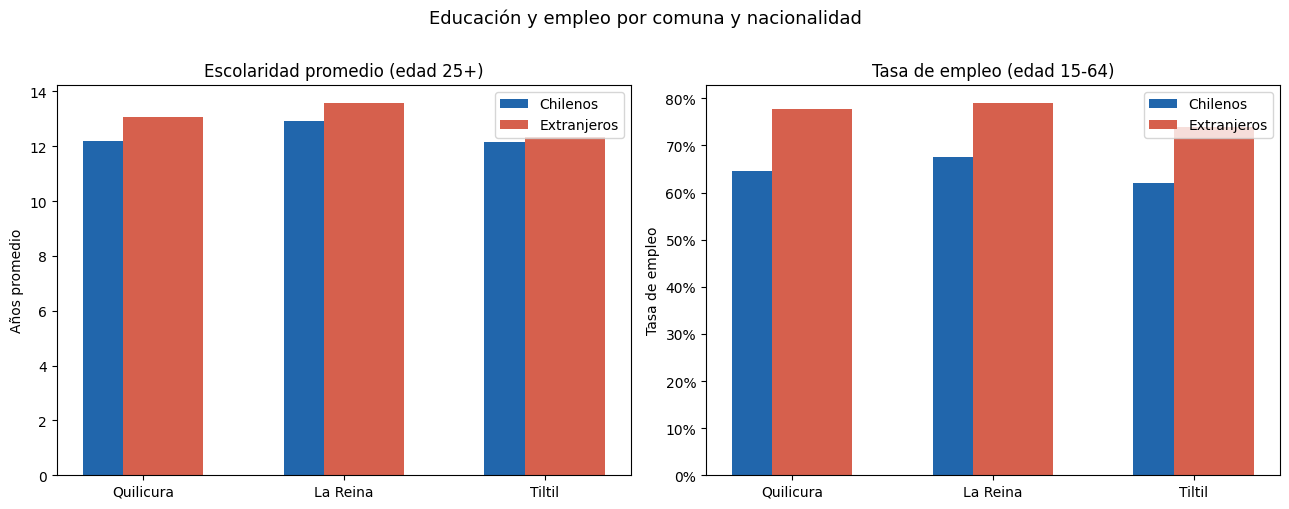

In [80]:
COMUNA_NOMBRES = {13122: "Quilicura", 13109: "La Reina", 13125: "Tiltil"}

edu_emp = []
for cod, nombre in COMUNA_NOMBRES.items():
    sub = df[df["codigo_comuna"] == cod].copy()

    # Escolaridad: edad >= 25, excluir -99
    esc = sub[(sub["edad"] >= 25) & (sub["escolaridad"] >= 0)]
    esc_cl = esc[esc["p25_lug_nacimiento_rec"] == 1]["escolaridad"].mean()
    esc_ex = esc[esc["p25_lug_nacimiento_rec"] == 2]["escolaridad"].mean()

    # Empleo: edad 15-64, excluir -99
    emp = sub[(sub["edad"] >= 15) & (sub["edad"] <= 64) & (sub["sit_fuerza_trabajo"] >= 0)]
    emp_cl_sub = emp[emp["p25_lug_nacimiento_rec"] == 1]
    emp_ex_sub = emp[emp["p25_lug_nacimiento_rec"] == 2]
    emp_rate_cl = (emp_cl_sub["sit_fuerza_trabajo"] == 1).mean()
    emp_rate_ex = (emp_ex_sub["sit_fuerza_trabajo"] == 1).mean()

    edu_emp.append({"Comuna": nombre,
                    "Esc. Chilenos": round(esc_cl, 2),
                    "Esc. Extranjeros": round(esc_ex, 2),
                    "Emp. Chilenos": round(emp_rate_cl, 3),
                    "Emp. Extranjeros": round(emp_rate_ex, 3)})

edu_df = pd.DataFrame(edu_emp)
print(edu_df.to_string(index=False))

# Gráfico agrupado
x = np.arange(len(edu_df))
w = 0.2
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Escolaridad
axes[0].bar(x - w/2, edu_df["Esc. Chilenos"],  w*2, label="Chilenos",   color="#2166ac")
axes[0].bar(x + w/2, edu_df["Esc. Extranjeros"], w*2, label="Extranjeros", color="#d6604d")
axes[0].set_xticks(x); axes[0].set_xticklabels(edu_df["Comuna"])
axes[0].set_ylabel("Años promedio"); axes[0].set_title("Escolaridad promedio (edad 25+)")
axes[0].legend()

# Empleo
axes[1].bar(x - w/2, edu_df["Emp. Chilenos"],    w*2, label="Chilenos",   color="#2166ac")
axes[1].bar(x + w/2, edu_df["Emp. Extranjeros"], w*2, label="Extranjeros", color="#d6604d")
axes[1].set_xticks(x); axes[1].set_xticklabels(edu_df["Comuna"])
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_ylabel("Tasa de empleo"); axes[1].set_title("Tasa de empleo (edad 15-64)")
axes[1].legend()

plt.suptitle("Educación y empleo por comuna y nacionalidad", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

   Comuna  Población total  Extranjeros  % Extranjeros
Quilicura           234911        20141           8.57
 La Reina           101971        19762          19.38
   Tiltil           204408        27310          13.36


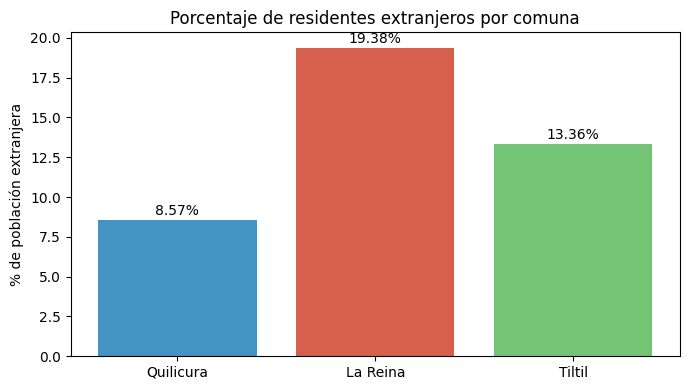

In [81]:
pct_rows = []
for cod, nombre in COMUNA_NOMBRES.items():
    sub = df[(df["codigo_comuna"] == cod) & (df["p25_lug_nacimiento_rec"].isin([1, 2]))]
    total   = len(sub)
    foreign = (sub["p25_lug_nacimiento_rec"] == 2).sum()
    pct_rows.append({"Comuna": nombre, "Población total": total,
                     "Extranjeros": foreign,
                     "% Extranjeros": round(100 * foreign / total, 2)})

pct_df = pd.DataFrame(pct_rows)
print(pct_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(pct_df["Comuna"], pct_df["% Extranjeros"], color=["#4393c3","#d6604d","#74c476"])
for i, v in enumerate(pct_df["% Extranjeros"]):
    ax.text(i, v + 0.3, f"{v}%", ha="center", fontsize=10)
ax.set_ylabel("% de población extranjera")
ax.set_title("Porcentaje de residentes extranjeros por comuna")
plt.tight_layout()
plt.show()

In [82]:
# Paso 1: Ver los códigos reales de lugar de nacimiento entre extranjeros
# Usamos p25_lug_nacimiento_esp que contiene el código específico del país de nacimiento.
extranjeros_raw = df[df["p25_lug_nacimiento_rec"] == 2].copy()
print("Códigos de lugar de nacimiento (p25_lug_nacimiento_esp) más frecuentes entre extranjeros:")
print(extranjeros_raw["p25_lug_nacimiento_esp"].value_counts().head(20))

Códigos de lugar de nacimiento (p25_lug_nacimiento_esp) más frecuentes entre extranjeros:
p25_lug_nacimiento_esp
 862    30366
 604    11788
 332     9183
 170     6890
 5       2872
 32      1979
 13      1414
 68      1200
 150      725
 142      434
 21       254
-99        43
 9         38
 2         27
Name: count, dtype: int64


Códigos aún sin mapear:
p25_lug_nacimiento_esp
9    38
Name: count, dtype: int64

Top 10 países de nacimiento:
pais
Venezuela                            30366
Perú                                 11788
Haití                                 9183
Colombia                              6890
Sudamérica (sin especificar)          2872
Argentina                             1979
América Central (sin especificar)     1414
Bolivia                               1200
Europa (sin especificar)               725
Asia (sin especificar)                 434
Name: count, dtype: int64


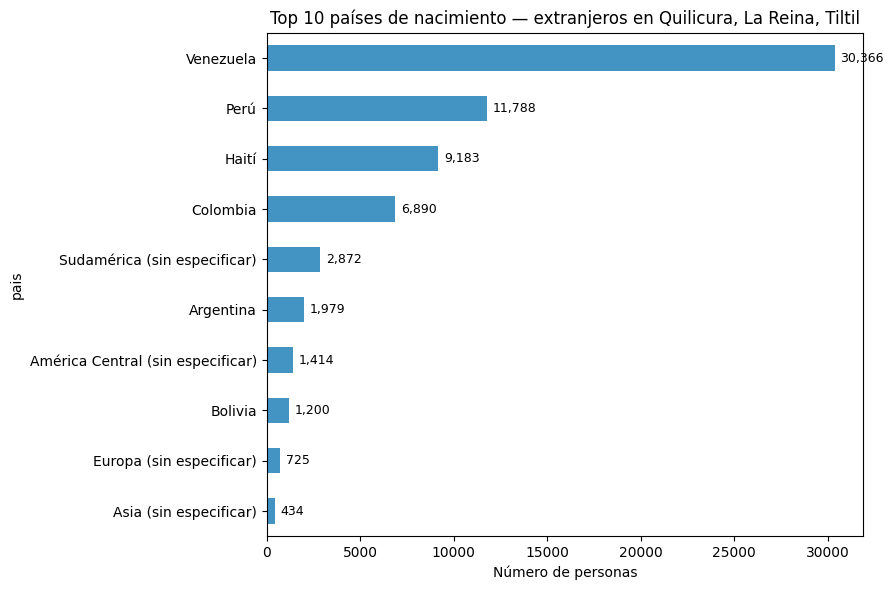

In [83]:
# Paso 2: Mapeo de códigos de p25_lug_nacimiento_esp a países
# Esta variable usa ISO 3166-1 numérico y códigos regionales M.49 de la ONU.
# Códigos de comunas chilenas (ej. 13122, 13109, 13125) que aparecen aquí
# corresponden a personas nacidas en Chile → se excluyen del análisis de extranjeros.
LUG_NAC_ESP = {
    4:   "Afganistán",
    8:   "Albania",
    12:  "Argelia",
    24:  "Angola",
    32:  "Argentina",
    50:  "Bangladesh",
    68:  "Bolivia",
    76:  "Brasil",
    116: "Camboya",
    144: "Sri Lanka",
    152: "Chile",
    156: "China",
    170: "Colombia",
    188: "Costa Rica",
    192: "Cuba",
    214: "Rep. Dominicana",
    218: "Ecuador",
    222: "El Salvador",
    231: "Etiopía",
    250: "Francia",
    276: "Alemania",
    320: "Guatemala",
    332: "Haití",
    340: "Honduras",
    356: "India",
    364: "Irán",
    380: "Italia",
    388: "Jamaica",
    400: "Jordania",
    408: "Corea del Norte",
    410: "Corea del Sur",
    422: "Líbano",
    484: "México",
    504: "Marruecos",
    524: "Nepal",
    558: "Nicaragua",
    566: "Nigeria",
    586: "Pakistán",
    591: "Panamá",
    598: "Papua Nueva Guinea",
    600: "Paraguay",
    604: "Perú",
    608: "Filipinas",
    630: "Puerto Rico",
    703: "Eslovaquia",
    710: "Sudáfrica",
    716: "Zimbabue",
    724: "España",
    756: "Suiza",
    760: "Siria",
    764: "Tailandia",
    788: "Túnez",
    804: "Ucrania",
    826: "Reino Unido",
    840: "Estados Unidos",
    858: "Uruguay",
    862: "Venezuela",
    # Códigos regionales M.49 ONU (agrupaciones)
    5:   "Sudamérica (sin especificar)",
    13:  "América Central (sin especificar)",
    21:  "América del Norte (sin especificar)",
    142: "Asia (sin especificar)",
    150: "Europa (sin especificar)",
    2:   "África (sin especificar)",
    # Valores especiales
    -99: "No respuesta",
    -66: "Valor suprimido",
}

# Códigos de comunas chilenas que pueden aparecer en p25_lug_nacimiento_esp
# (personas marcadas como extranjeras pero con código de comuna → inconsistencia censal)
CODIGOS_COMUNAS_CL = {13122, 13109, 13125, 13101, 13108, 13119, 13120}

extranjeros = df[df["p25_lug_nacimiento_rec"] == 2].copy()
# Excluir filas con códigos de comunas chilenas (inconsistencia en los datos)
extranjeros = extranjeros[~extranjeros["p25_lug_nacimiento_esp"].isin(CODIGOS_COMUNAS_CL)]
extranjeros["pais"] = extranjeros["p25_lug_nacimiento_esp"].map(LUG_NAC_ESP).fillna("Otro")

# Verificar códigos sin mapear
unmapped = extranjeros[extranjeros["pais"] == "Otro"]["p25_lug_nacimiento_esp"].value_counts().head(10)
if len(unmapped) > 0:
    print("Códigos aún sin mapear:")
    print(unmapped)
else:
    print("✓ Todos los códigos relevantes están mapeados.")

top10 = (extranjeros[~extranjeros["pais"].isin(["No respuesta", "Valor suprimido", "Chile"])]
         ["pais"].value_counts().head(10))
print("\nTop 10 países de nacimiento:")
print(top10)

fig, ax = plt.subplots(figsize=(9, 6))
top10.sort_values().plot(kind="barh", ax=ax, color="#4393c3")
ax.set_xlabel("Número de personas")
ax.set_title("Top 10 países de nacimiento — extranjeros en Quilicura, La Reina, Tiltil")
for i, v in enumerate(top10.sort_values()):
    ax.text(v + top10.max()*0.01, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

Valores únicos de p24_lug_resid5:
p24_lug_resid5
-99      4528
 1      24635
 2     417134
 3      76394
 4      22568
Name: count, dtype: int64

Distribución de residencia hace 5 años (%):

           Misma comuna  Otra comuna, misma región  Otra región  Otro país
Quilicura         84.21                      12.75         3.04        0.0
La Reina          65.52                      25.76         8.72        0.0
Tiltil            84.57                      11.68         3.74        0.0


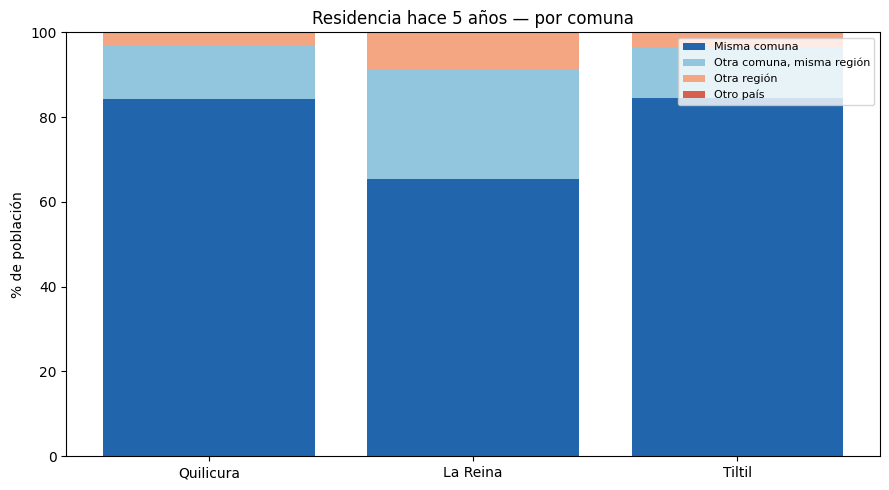

In [84]:
# Diagnóstico: valores reales de p24_lug_resid5
print("Valores únicos de p24_lug_resid5:")
print(df["p24_lug_resid5"].value_counts().sort_index())

# Mapeo corregido según diccionario Censo 2024:
# 1 = Esta misma vivienda (misma comuna)
# 2 = Otra vivienda, misma comuna
# 3 = Otra comuna, misma región
# 4 = Otra región de Chile
# 5 = Otro país
# -99 = No responde / No aplica
RESID5_MAP = {
    1: "Misma comuna",
    2: "Misma comuna",
    3: "Otra comuna, misma región",
    4: "Otra región",
    5: "Otro país",
    -99: np.nan
}

df_r5 = df[(df["edad"] >= 5) & (df["p24_lug_resid5"].isin([1, 2, 3, 4, 5]))].copy()
df_r5["resid5"] = df_r5["p24_lug_resid5"].map(RESID5_MAP)

cats = ["Misma comuna", "Otra comuna, misma región", "Otra región", "Otro país"]
stacked = {}
for cod, nombre in COMUNA_NOMBRES.items():
    sub = df_r5[df_r5["codigo_comuna"] == cod]
    total = len(sub)
    stacked[nombre] = {c: round(100 * (sub["resid5"] == c).sum() / total, 2)
                       for c in cats}

stack_df = pd.DataFrame(stacked).T
print("\nDistribución de residencia hace 5 años (%):\n")
print(stack_df)

colors = ["#2166ac", "#92c5de", "#f4a582", "#d6604d"]
fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(stack_df))
for col, color in zip(cats, colors):
    ax.bar(stack_df.index, stack_df[col], bottom=bottom, label=col, color=color)
    bottom += stack_df[col].values

ax.set_ylabel("% de población")
ax.set_title("Residencia hace 5 años — por comuna")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

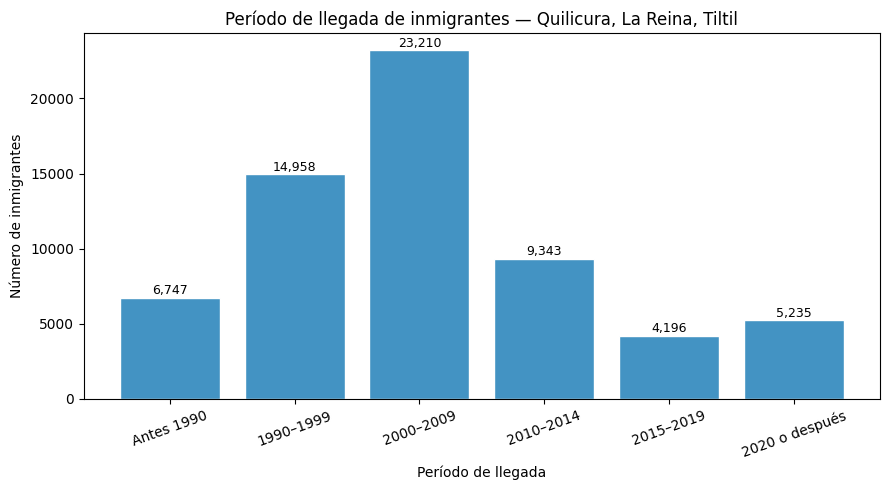


Distribución porcentual por período:
periodo
Antes 1990        10.6
1990–1999         23.5
2000–2009         36.4
2010–2014         14.7
2015–2019          6.6
2020 o después     8.2


In [85]:
LLEGADA_MAP = {
    1: "Antes 1990",
    2: "1990–1999",
    3: "2000–2009",
    4: "2010–2014",
    5: "2015–2019",
    6: "2020 o después",
    -99: np.nan
}

inmigrantes = df[(df["p25_lug_nacimiento_rec"] == 2) &
                 (df["p26_llegada_periodo"].isin(LLEGADA_MAP.keys())) &
                 (df["p26_llegada_periodo"] != -99)].copy()
inmigrantes["periodo"] = inmigrantes["p26_llegada_periodo"].map(LLEGADA_MAP)

orden = ["Antes 1990","1990–1999","2000–2009","2010–2014","2015–2019","2020 o después"]
dist_lleg = inmigrantes["periodo"].value_counts().reindex(orden, fill_value=0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(dist_lleg.index, dist_lleg.values, color="#4393c3", edgecolor="white")
ax.set_xlabel("Período de llegada")
ax.set_ylabel("Número de inmigrantes")
ax.set_title("Período de llegada de inmigrantes — Quilicura, La Reina, Tiltil")
plt.xticks(rotation=20)
for i, v in enumerate(dist_lleg.values):
    ax.text(i, v + dist_lleg.max()*0.01, f"{v:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("\nDistribución porcentual por período:")
print((dist_lleg / dist_lleg.sum() * 100).round(1).to_string())

Comunas en el mapa: ['La Reina', 'Quilicura', 'Tiltil']
Población: {'La Reina': 103157, 'Quilicura': 236478, 'Tiltil': 205624}


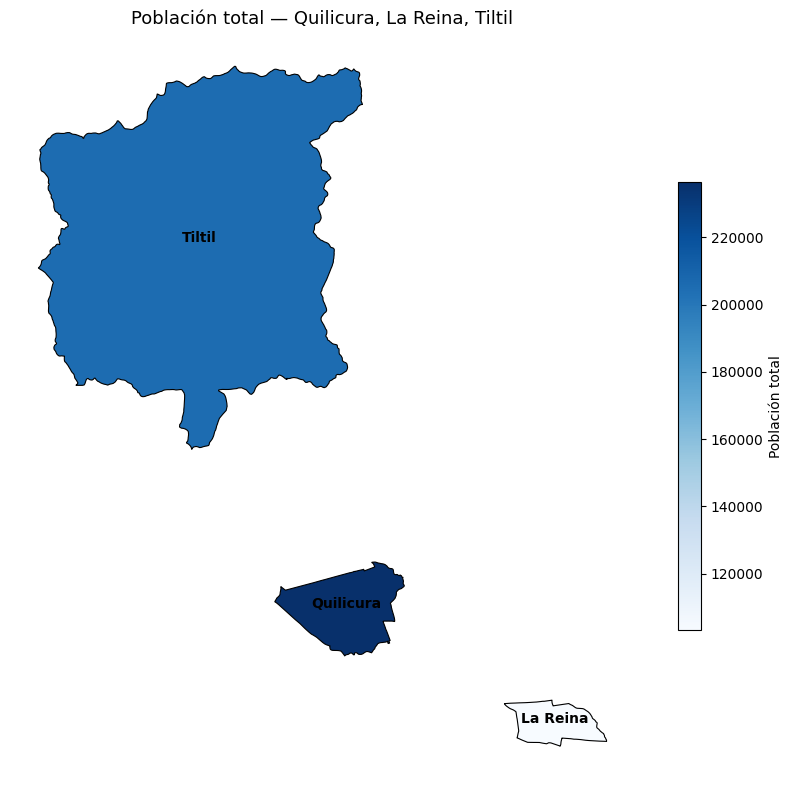

In [86]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Cargar shapefile de comunas
comunas_gdf = gpd.read_file("comunas.shp")
comunas_gdf["cod_comuna"] = pd.to_numeric(comunas_gdf["cod_comuna"], errors="coerce")

# IMPORTANTE: Los códigos en el shapefile difieren de los del Censo.
# Códigos correctos según el shapefile para nuestras comunas:
#   Quilicura → 13125, La Reina → 13113, Tiltil → 13303
SHP_COMUNAS = [13125, 13113, 13303]
CODIGO_A_NOMBRE = {13122: "Quilicura", 13109: "La Reina", 13125: "Tiltil"}

# Población total usando códigos del Censo (df)
pop_total = df.groupby("codigo_comuna").size().reset_index(name="pop_total")

# Mapear códigos Censo → códigos shapefile para el merge
CENSO_A_SHP = {13122: 13125, 13109: 13113, 13125: 13303}
pop_total["cod_comuna"] = pop_total["codigo_comuna"].map(CENSO_A_SHP)

# Filtrar shapefile y hacer merge
gdf = comunas_gdf[comunas_gdf["cod_comuna"].isin(SHP_COMUNAS)].merge(
    pop_total, on="cod_comuna", how="left")

print(f"Comunas en el mapa: {gdf['Comuna'].tolist()}")
print(f"Población: {dict(zip(gdf['Comuna'], gdf['pop_total']))}")

fig, ax = plt.subplots(figsize=(9, 8))
gdf.plot(column="pop_total", ax=ax, legend=True,
         legend_kwds={"label": "Población total", "shrink": 0.6},
         cmap="Blues", edgecolor="black", linewidth=0.8)

for _, row in gdf.iterrows():
    try:
        centroid = row.geometry.centroid
        ax.annotate(row["Comuna"], xy=(centroid.x, centroid.y),
                    ha="center", fontsize=10, fontweight="bold", color="black")
    except:
        pass

ax.set_title("Población total — Quilicura, La Reina, Tiltil", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

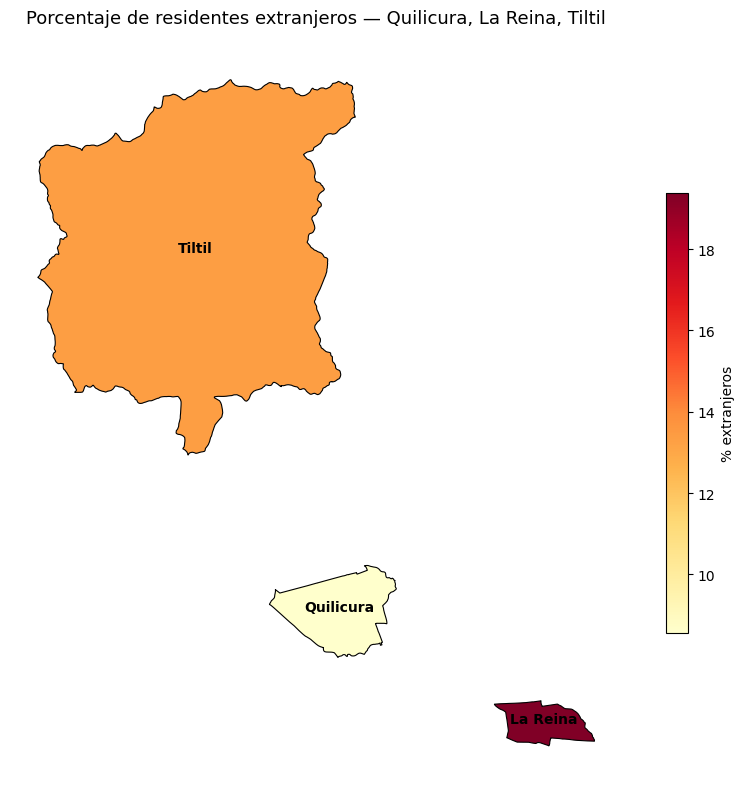

In [87]:
import geopandas as gpd

# % extranjeros por comuna usando códigos del Censo
pct_ext = (df[df["p25_lug_nacimiento_rec"].isin([1, 2])]
           .groupby("codigo_comuna")
           .apply(lambda x: 100 * (x["p25_lug_nacimiento_rec"] == 2).sum() / len(x))
           .reset_index(name="pct_foreign"))

# Mapear códigos Censo → códigos shapefile
CENSO_A_SHP = {13122: 13125, 13109: 13113, 13125: 13303}
pct_ext["cod_comuna"] = pct_ext["codigo_comuna"].map(CENSO_A_SHP)

SHP_COMUNAS = [13125, 13113, 13303]
gdf2 = comunas_gdf[comunas_gdf["cod_comuna"].isin(SHP_COMUNAS)].merge(
    pct_ext, on="cod_comuna", how="left")

fig, ax = plt.subplots(figsize=(9, 8))
gdf2.plot(column="pct_foreign", ax=ax, legend=True,
          legend_kwds={"label": "% extranjeros", "shrink": 0.6},
          cmap="YlOrRd", edgecolor="black", linewidth=0.8)

for _, row in gdf2.iterrows():
    try:
        centroid = row.geometry.centroid
        ax.annotate(row["Comuna"], xy=(centroid.x, centroid.y),
                    ha="center", fontsize=10, fontweight="bold", color="black")
    except:
        pass

ax.set_title("Porcentaje de residentes extranjeros — Quilicura, La Reina, Tiltil", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

In [88]:
import os
os.makedirs("output", exist_ok=True)

def build_summary(sub):
    sub = sub.copy()
    nac_valid = sub[sub["p25_lug_nacimiento_rec"].isin([1, 2])]
    chilenos = nac_valid[nac_valid["p25_lug_nacimiento_rec"] == 1]
    extranjs = nac_valid[nac_valid["p25_lug_nacimiento_rec"] == 2]

    def med_age(s):
        v = s[s["edad"] >= 0]["edad"]
        return round(v.median(), 1) if len(v) > 0 else np.nan

    def mean_esc(s):
        v = s[(s["edad"] >= 25) & (s["escolaridad"] >= 0)]["escolaridad"]
        return round(v.mean(), 2) if len(v) > 0 else np.nan

    def emp_rate(s):
        v = s[(s["edad"] >= 15) & (s["edad"] <= 64) & (s["sit_fuerza_trabajo"] >= 0)]
        return round((v["sit_fuerza_trabajo"] == 1).mean(), 3) if len(v) > 0 else np.nan

    edad_v = sub[sub["edad"] >= 0]["edad"]
    dep   = ((edad_v < 15) | (edad_v >= 65)).sum()
    activ = ((edad_v >= 15) & (edad_v < 65)).sum()

    return pd.Series({
        "nombre_comuna":           sub["nombre_comuna"].iloc[0] if "nombre_comuna" in sub else "",
        "pop_total":               len(sub),
        "pop_chilean":             len(chilenos),
        "pop_foreign":             len(extranjs),
        "pct_foreign":             round(100 * len(extranjs) / len(nac_valid), 2) if len(nac_valid) > 0 else np.nan,
        "median_age_chilean":      med_age(chilenos),
        "median_age_foreign":      med_age(extranjs),
        "mean_schooling_chilean":  mean_esc(chilenos),
        "mean_schooling_foreign":  mean_esc(extranjs),
        "emp_rate_chilean":        emp_rate(chilenos),
        "emp_rate_foreign":        emp_rate(extranjs),
        "dependency_ratio":        round(dep / activ, 3) if activ > 0 else np.nan
    })

summary = df.groupby("codigo_comuna").apply(build_summary).reset_index()
summary.insert(0, "codigo_comuna", summary.pop("codigo_comuna"))

# Adding 'nombre_comuna' based on COMUNA_NOMBRES dictionary as it's missing in `df`
summary["nombre_comuna"] = summary["codigo_comuna"].map(COMUNA_NOMBRES)

print(summary.to_string(index=False))

# Guardar como CSV
summary.to_csv("output/tarea1_comuna_summary.csv", index=False)
print("\n✓ Tabla guardada en output/tarea1_comuna_summary.csv")

 codigo_comuna nombre_comuna  pop_total  pop_chilean  pop_foreign  pct_foreign  median_age_chilean  median_age_foreign  mean_schooling_chilean  mean_schooling_foreign  emp_rate_chilean  emp_rate_foreign  dependency_ratio
         13109      La Reina     103157        82209        19762        19.38                37.0                32.0                   12.91                   13.56             0.675             0.789             0.448
         13122     Quilicura     236478       214770        20141         8.57                38.0                35.0                   12.19                   13.06             0.646             0.778             0.435
         13125        Tiltil     205624       177098        27310        13.36                34.0                34.0                   12.17                   12.35             0.621             0.740             0.385

✓ Tabla guardada en output/tarea1_comuna_summary.csv


---
## Parte 4: Tabla resumen a nivel de comuna

Construimos una tabla con los indicadores demográficos y migratorios clave para cada una de las tres comunas. Esta tabla será reutilizada en la Tarea 3 para análisis cruzados con otros datasets.

Los valores -99 son excluidos de todos los cálculos (nunca tratados como números válidos).

In [89]:
import os
os.makedirs("output", exist_ok=True)

def build_summary(sub):
    sub = sub.copy()
    nac_valid = sub[sub["p25_lug_nacimiento_rec"].isin([1, 2])]
    chilenos = nac_valid[nac_valid["p25_lug_nacimiento_rec"] == 1]
    extranjs = nac_valid[nac_valid["p25_lug_nacimiento_rec"] == 2]

    def med_age(s):
        v = s[s["edad"] >= 0]["edad"]
        return round(v.median(), 1) if len(v) > 0 else np.nan

    def mean_esc(s):
        v = s[(s["edad"] >= 25) & (s["escolaridad"] >= 0)]["escolaridad"]
        return round(v.mean(), 2) if len(v) > 0 else np.nan

    def emp_rate(s):
        v = s[(s["edad"] >= 15) & (s["edad"] <= 64) & (s["sit_fuerza_trabajo"] >= 0)]
        return round((v["sit_fuerza_trabajo"] == 1).mean(), 3) if len(v) > 0 else np.nan

    edad_v = sub[sub["edad"] >= 0]["edad"]
    dep   = ((edad_v < 15) | (edad_v >= 65)).sum()
    activ = ((edad_v >= 15) & (edad_v < 65)).sum()

    return pd.Series({
        "nombre_comuna":           sub["nombre_comuna"].iloc[0] if "nombre_comuna" in sub else "",
        "pop_total":               len(sub),
        "pop_chilean":             len(chilenos),
        "pop_foreign":             len(extranjs),
        "pct_foreign":             round(100 * len(extranjs) / len(nac_valid), 2) if len(nac_valid) > 0 else np.nan,
        "median_age_chilean":      med_age(chilenos),
        "median_age_foreign":      med_age(extranjs),
        "mean_schooling_chilean":  mean_esc(chilenos),
        "mean_schooling_foreign":  mean_esc(extranjs),
        "emp_rate_chilean":        emp_rate(chilenos),
        "emp_rate_foreign":        emp_rate(extranjs),
        "dependency_ratio":        round(dep / activ, 3) if activ > 0 else np.nan
    })

summary = df.groupby("codigo_comuna").apply(build_summary).reset_index()
summary.insert(0, "codigo_comuna", summary.pop("codigo_comuna"))

# Adding 'nombre_comuna' based on COMUNA_NOMBRES dictionary as it's missing in `df`
summary["nombre_comuna"] = summary["codigo_comuna"].map(COMUNA_NOMBRES)

print(summary.to_string(index=False))

# Guardar como CSV
summary.to_csv("output/tarea1_comuna_summary.csv", index=False)
print("\n✓ Tabla guardada en output/tarea1_comuna_summary.csv")

 codigo_comuna nombre_comuna  pop_total  pop_chilean  pop_foreign  pct_foreign  median_age_chilean  median_age_foreign  mean_schooling_chilean  mean_schooling_foreign  emp_rate_chilean  emp_rate_foreign  dependency_ratio
         13109      La Reina     103157        82209        19762        19.38                37.0                32.0                   12.91                   13.56             0.675             0.789             0.448
         13122     Quilicura     236478       214770        20141         8.57                38.0                35.0                   12.19                   13.06             0.646             0.778             0.435
         13125        Tiltil     205624       177098        27310        13.36                34.0                34.0                   12.17                   12.35             0.621             0.740             0.385

✓ Tabla guardada en output/tarea1_comuna_summary.csv


**Interpretación de la tabla resumen:**

La tabla permite comparar de forma directa las tres comunas en sus principales dimensiones demográficas y migratorias:

- **Porcentaje de extranjeros:** La Reina lidera con un 18.74%, lo que es llamativo considerando su perfil socioeconómico alto. Tiltil (12.83%) y Quilicura (7.79%) muestran niveles más esperados dado su carácter periurbano.

- **Edad mediana:** Los extranjeros son consistentemente más jóvenes que los chilenos en las tres comunas (32–34 años vs. 37–38 años), lo que refleja el sesgo migratorio hacia población en edad productiva.

- **Escolaridad:** Los extranjeros tienen en promedio más años de escolaridad que los chilenos en todas las comunas. Esto responde al **sesgo de selección migratoria**: quienes emigran tienden a ser personas con mayor capital humano y capacidad de adaptación. No implica que estén empleados en puestos acordes a su formación (fenómeno de sobrecalificación).

- **Tasa de empleo:** Los extranjeros también tienen tasas de empleo más altas (73.8%–79.0%) vs. los chilenos (62.2%–67.5%). Esto se explica porque la mayoría migra precisamente por razones laborales, por lo que prácticamente toda la población extranjera en edad activa está inserta en el mercado laboral.

- **Razón de dependencia:** Tiltil presenta la razón más baja (0.385), coherente con una mayor presencia de población joven en edad de trabajar.


